
The following simulation is an attempt to simulate a Hodgkin Huxley Neuron model

Equation of model:
    
    C*du/dt=-g(Na)m^3h(u-E(Na))-g(K)n^4(u-E(K))-g(L)(u-E(L))+I(t)
    
and:
    
    dx/dt=-(x-x0(u))/Ta(u,x)  (For x=m,n,h)



In [1]:
import numpy as np

def hodgkin_huxley_equations(V, n, m, h, I_app):
    # Model Parameters (standard values, can be adjusted)
    C_m = 1.0   # membrane capacitance, in uF/cm^2
    g_Na = 120.0  # maximum sodium conductance, in mS/cm^2
    g_K = 36.0   # maximum potassium conductance, in mS/cm^2
    g_L = 0.3    # maximum leak conductance, in mS/cm^2
    E_Na = 50.0  # sodium reversal potential, in mV
    E_K = -77.0  # potassium reversal potential, in mV
    E_L = -54.387 # leak reversal potential, in mV

    # 1. Alpha and Beta Functions for Gating Variables
    # Potassium activation (n)
    alpha_n = lambda V: 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1) if V != 10 else 0.1
    beta_n = lambda V: 0.125 * np.exp(-V / 80)

    # Sodium activation (m)
    alpha_m = lambda V: 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1) if V != 25 else 1.0
    beta_m = lambda V: 4.0 * np.exp(-V / 18)

    # Sodium inactivation (h)
    alpha_h = lambda V: 0.07 * np.exp(-V / 20)
    beta_h = lambda V: 1.0 / (np.exp((30 - V) / 10) + 1)

    # 2. Steady-State Values and Time Constants
    # Potassium activation (n)
    n_inf = alpha_n(V) / (alpha_n(V) + beta_n(V))
    tau_n = 1 / (alpha_n(V) + beta_n(V))

    # Sodium activation (m)
    m_inf = alpha_m(V) / (alpha_m(V) + beta_m(V))
    tau_m = 1 / (alpha_m(V) + beta_m(V))

    # Sodium inactivation (h)
    h_inf = alpha_h(V) / (alpha_h(V) + beta_h(V))
    tau_h = 1 / (alpha_h(V) + beta_h(V))

    # Ionic Currents
    I_Na = g_Na * m**3 * h * (V - E_Na)  # Sodium current
    I_K = g_K * n**4 * (V - E_K)      # Potassium current
    I_L = g_L * (V - E_L)           # Leak current

    # 3. Differential Equation for Membrane Potential (dV/dt)
    dVdt = (I_app - I_Na - I_K - I_L) / C_m

    # 4. Differential Equations for Gating Variables (dX/dt)
    dndt = (n_inf - n) / tau_n
    dmdt = (m_inf - m) / tau_m
    dhdt = (h_inf - h) / tau_h

    return dVdt, dndt, dmdt, dhdt, n_inf, m_inf, h_inf, tau_n, tau_m, tau_h

print("Hodgkin-Huxley equations defined successfully, including alpha/beta functions, steady-state values, time constants, and differential equations.")

Hodgkin-Huxley equations defined successfully, including alpha/beta functions, steady-state values, time constants, and differential equations.


The previous cell uses the alpha beta formulation of the gating variables. Alpha refers to the rate of any of the channels opening up, and beta refers to the rate at which any of the channels close down.

In this case, m, n and h can be defined as the fraction of any channel of the respective type being open (or probability)

The relevant equations are:

    dx/dt=alpha(x,u)(1-x)-beta(x,u)(x)

Where, x is m, n or h, and u is the voltage of the neuronal cell membrane.

This would imply:

    x0(u)=alpha(x,u)/(alpha(x,u)+beta(x,u))

    t(x,u)=1/(alpha(x,u)+beta(x,u))

In [2]:
C_m = 1.0   # membrane capacitance, in uF/cm^2
g_Na = 120.0  # maximum sodium conductance, in mS/cm^2
g_K = 36.0   # maximum potassium conductance, in mS/cm^2
g_L = 0.3    # maximum leak conductance, in mS/cm^2
E_Na = 50.0  # sodium reversal potential, in mV
E_K = -77.0  # potassium reversal potential, in mV
E_L = -54.387 # leak reversal potential, in mV

# Initial conditions (resting potential around -65mV, relative to E_Na of 50mV and E_K of -77mV)
V_0 = -65.0 # Initial membrane potential, in mV

# Calculate steady-state gating variables at V_0
# We need the alpha and beta functions from hodgkin_huxley_equations
# To avoid calling the full function and returning dVdt etc., we can re-define
# the alpha/beta functions locally or refactor the previous code.
# For now, we will extract the relevant parts to calculate n_inf, m_inf, h_inf at V_0.

# Alpha and Beta Functions for Gating Variables (extracted for initial condition calculation)
alpha_n_func = lambda V: 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1) if V != 10 else 0.1
beta_n_func = lambda V: 0.125 * np.exp(-V / 80)

alpha_m_func = lambda V: 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1) if V != 25 else 1.0
beta_m_func = lambda V: 4.0 * np.exp(-V / 18)

alpha_h_func = lambda V: 0.07 * np.exp(-V / 20)
beta_h_func = lambda V: 1.0 / (np.exp((30 - V) / 10) + 1)

# Steady-state values at V_0
n_0 = alpha_n_func(V_0) / (alpha_n_func(V_0) + beta_n_func(V_0))
m_0 = alpha_m_func(V_0) / (alpha_m_func(V_0) + beta_m_func(V_0))
h_0 = alpha_h_func(V_0) / (alpha_h_func(V_0) + beta_h_func(V_0))

print(f"Fixed Model Parameters:")
print(f"  C_m = {C_m} uF/cm^2")
print(f"  g_Na = {g_Na} mS/cm^2, E_Na = {E_Na} mV")
print(f"  g_K = {g_K} mS/cm^2, E_K = {E_K} mV")
print(f"  g_L = {g_L} mS/cm^2, E_L = {E_L} mV")
print(f"\nInitial Conditions at V_0 = {V_0} mV:")
print(f"  n_0 = {n_0:.4f}")
print(f"  m_0 = {m_0:.4f}")
print(f"  h_0 = {h_0:.4f}")

Fixed Model Parameters:
  C_m = 1.0 uF/cm^2
  g_Na = 120.0 mS/cm^2, E_Na = 50.0 mV
  g_K = 36.0 mS/cm^2, E_K = -77.0 mV
  g_L = 0.3 mS/cm^2, E_L = -54.387 mV

Initial Conditions at V_0 = -65.0 mV:
  n_0 = 0.0015
  m_0 = 0.0000
  h_0 = 1.0000


The expressions for alpha_n_func and alpha_m_func are defined with a conditional, to negate the mathematical error of division by 0 at the designated value of V. Hence, L'Hôpital's Rule is used to find the value that would be substituted at the designated V value.

In [16]:
dt = 0.01  # time step size (ms)
t_start = 0.0 # start time (ms)
t_end = 50.0 # end time (ms)
t = np.arange(t_start, t_end, dt) # time array

# Initialize arrays to store results
V_trace = np.zeros_like(t)
n_trace = np.zeros_like(t)
m_trace = np.zeros_like(t)
h_trace = np.zeros_like(t)

# Set initial conditions
V_trace[0] = V_0
n_trace[0] = n_0
m_trace[0] = m_0
h_trace[0] = h_0

# Define applied current (I_app)
I_app_trace = np.zeros_like(t)
# Apply a current pulse from 10ms to 11ms
I_start_idx = int(10 / dt)
I_end_idx = int(11 / dt)
I_app_trace[I_start_idx:I_end_idx] = 30.0 # uA/cm^2 (Increased for spikiness)

# Numerical integration using Forward Euler method
for i in range(len(t) - 1):
    current_V = V_trace[i]
    current_n = n_trace[i]
    current_m = m_trace[i]
    current_h = h_trace[i]
    current_I_app = I_app_trace[i]

    # Get derivatives and other values from the Hodgkin-Huxley equations
    dVdt, dndt, dmdt, dhdt, _, _, _, _, _, _ = hodgkin_huxley_equations(
        current_V, current_n, current_m, current_h, current_I_app
    )

    # Update state variables using Forward Euler
    V_trace[i+1] = current_V + dVdt * dt
    n_trace[i+1] = current_n + dndt * dt
    m_trace[i+1] = current_m + dmdt * dt
    h_trace[i+1] = current_h + dhdt * dt

print("Numerical simulation completed successfully.")

Numerical simulation completed successfully.


## Generate Graphical Plots

### Subtask:
Create plots to visualize the simulation results, including the membrane potential (V) over time and the gating variables (m, h, n) over time.


**Reasoning**:
The subtask requires generating graphical plots of the simulation results. This involves importing `matplotlib.pyplot`, creating two subplots for membrane potential and gating variables, plotting the respective traces, adding labels, titles, legends, and grid lines, and finally displaying the plots.



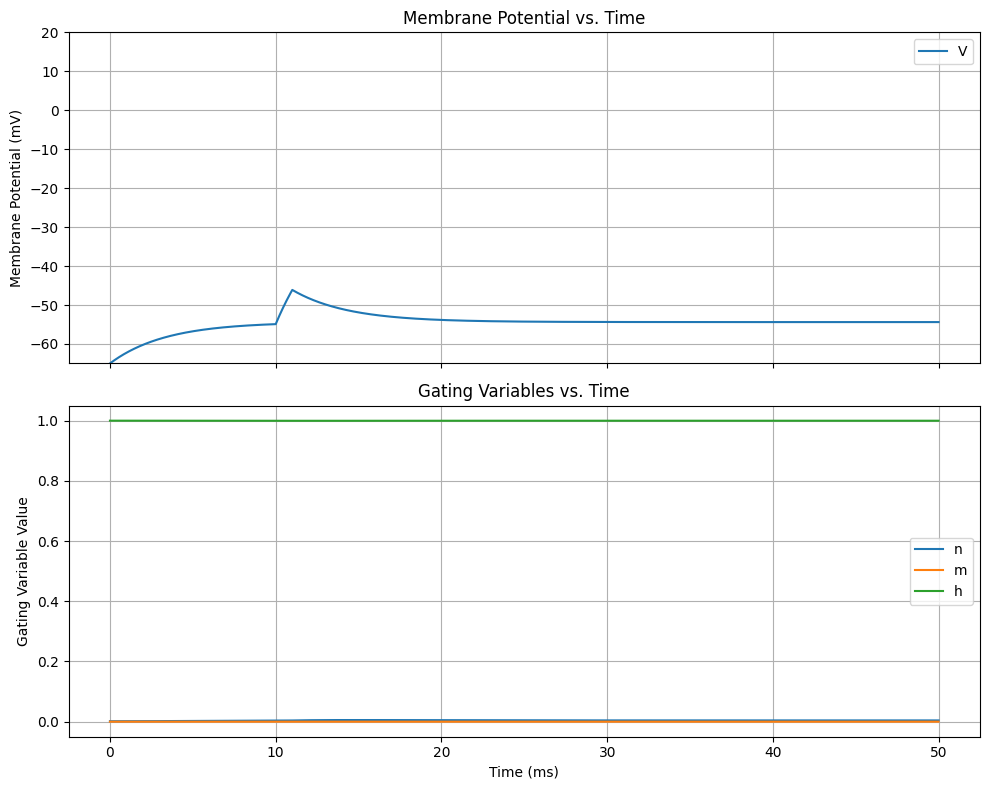

Plots for membrane potential and gating variables generated successfully.


In [13]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Membrane Potential (V) on the first subplot
ax1.plot(t, V_trace, label='V')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('Membrane Potential vs. Time')
ax1.set_ylim(-65, 20) # Set y-axis limits
ax1.grid(True)
ax1.legend()

# Plot Gating Variables (n, m, h) on the second subplot
ax2.plot(t, n_trace, label='n')
ax2.plot(t, m_trace, label='m')
ax2.plot(t, h_trace, label='h')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Gating Variable Value')
ax2.set_title('Gating Variables vs. Time')
ax2.grid(True)
ax2.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

print("Plots for membrane potential and gating variables generated successfully.")

## Detailed Gating Variable Plots

To better visualize the individual dynamics of the gating variables, especially 'm' and 'n' which have much smaller values than 'h' and V, we will create separate subplots for each variable.

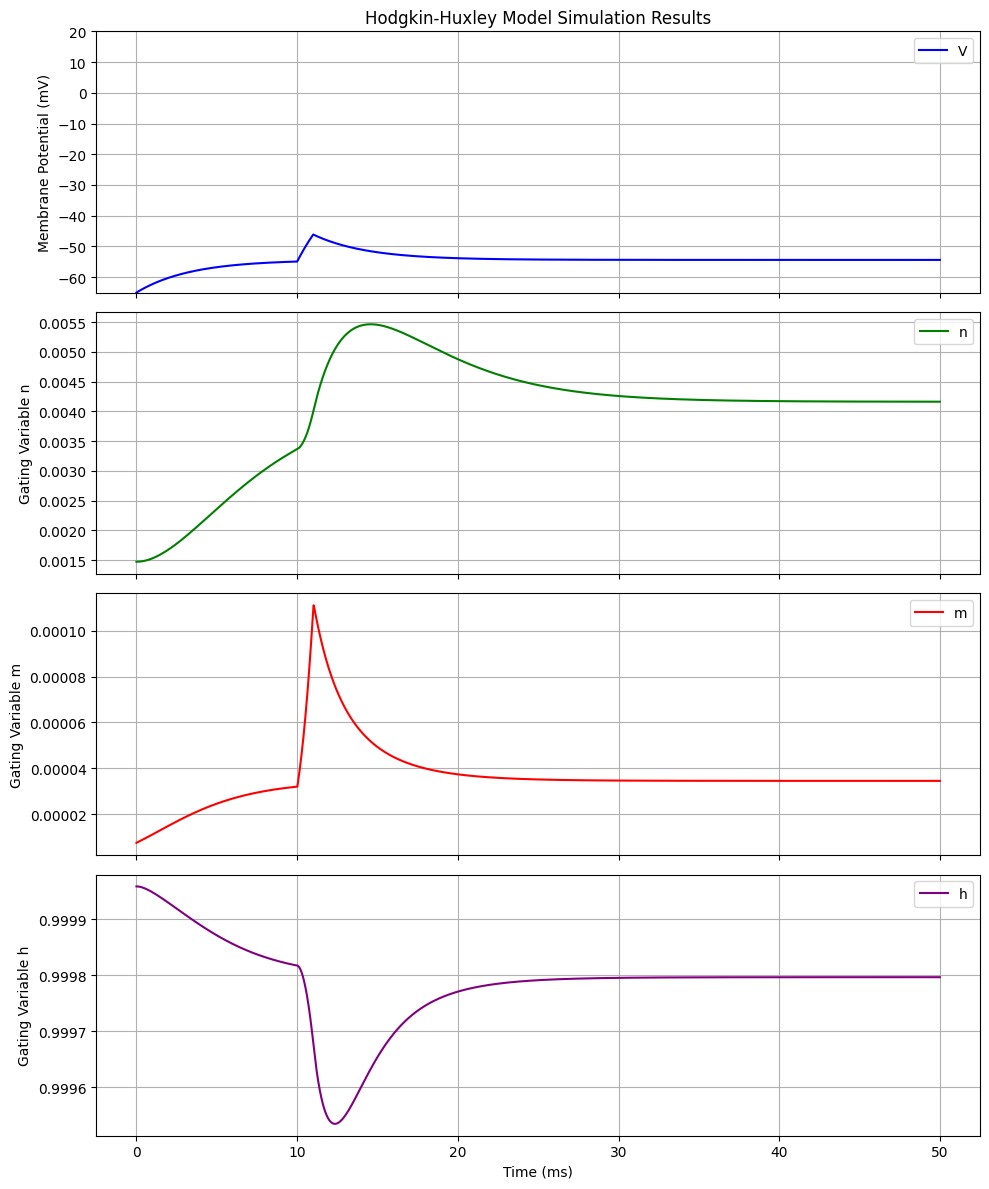

Detailed plots for membrane potential and individual gating variables generated successfully.


In [14]:
import matplotlib.pyplot as plt

# Create a figure with 4 subplots, sharing the x-axis (time)
fig, (ax_V, ax_n, ax_m, ax_h) = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# Plot Membrane Potential (V)
ax_V.plot(t, V_trace, label='V', color='blue')
ax_V.set_ylabel('Membrane Potential (mV)')
ax_V.set_title('Hodgkin-Huxley Model Simulation Results')
ax_V.set_ylim(-65, 20) # Set y-axis limits
ax_V.grid(True)
ax_V.legend()

# Plot Gating Variable n
ax_n.plot(t, n_trace, label='n', color='green')
ax_n.set_ylabel('Gating Variable n')
ax_n.grid(True)
ax_n.legend()

# Plot Gating Variable m
ax_m.plot(t, m_trace, label='m', color='red')
ax_m.set_ylabel('Gating Variable m')
ax_m.grid(True)
ax_m.legend()

# Plot Gating Variable h
ax_h.plot(t, h_trace, label='h', color='purple')
ax_h.set_xlabel('Time (ms)')
ax_h.set_ylabel('Gating Variable h')
ax_h.grid(True)
ax_h.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

print("Detailed plots for membrane potential and individual gating variables generated successfully.")

At the end, due to the nature of the hodgkin huxley equations being interdependent on each other, Euler method is a first approximation of the simulation. I am now going to try out another more advanced method.

In [6]:
import numpy as np

# Initialize arrays to store RK4 results
V_trace_rk4 = np.zeros_like(t)
n_trace_rk4 = np.zeros_like(t)
m_trace_rk4 = np.zeros_like(t)
h_trace_rk4 = np.zeros_like(t)

# Set initial conditions for RK4
V_trace_rk4[0] = V_0
n_trace_rk4[0] = n_0
m_trace_rk4[0] = m_0
h_trace_rk4[0] = h_0

# Numerical integration using RK4 method
for i in range(len(t) - 1):
    # Current state variables and applied current
    current_V = V_trace_rk4[i]
    current_n = n_trace_rk4[i]
    current_m = m_trace_rk4[i]
    current_h = h_trace_rk4[i]
    current_I_app = I_app_trace[i]

    # --- k1 calculations ---
    k1_dVdt, k1_dndt, k1_dmdt, k1_dhdt, _, _, _, _, _, _ = hodgkin_huxley_equations(
        current_V, current_n, current_m, current_h, current_I_app
    )

    # --- k2 calculations ---
    # Intermediate state variables for k2
    V_k2 = current_V + 0.5 * dt * k1_dVdt
    n_k2 = current_n + 0.5 * dt * k1_dndt
    m_k2 = current_m + 0.5 * dt * k1_dmdt
    h_k2 = current_h + 0.5 * dt * k1_dhdt

    k2_dVdt, k2_dndt, k2_dmdt, k2_dhdt, _, _, _, _, _, _ = hodgkin_huxley_equations(
        V_k2, n_k2, m_k2, h_k2, current_I_app
    )

    # --- k3 calculations ---
    # Intermediate state variables for k3
    V_k3 = current_V + 0.5 * dt * k2_dVdt
    n_k3 = current_n + 0.5 * dt * k2_dndt
    m_k3 = current_m + 0.5 * dt * k2_dmdt
    h_k3 = current_h + 0.5 * dt * k2_dhdt

    k3_dVdt, k3_dndt, k3_dmdt, k3_dhdt, _, _, _, _, _, _ = hodgkin_huxley_equations(
        V_k3, n_k3, m_k3, h_k3, current_I_app
    )

    # --- k4 calculations ---
    # Intermediate state variables for k4
    V_k4 = current_V + dt * k3_dVdt
    n_k4 = current_n + dt * k3_dndt
    m_k4 = current_m + dt * k3_dmdt
    h_k4 = current_h + dt * k3_dhdt

    k4_dVdt, k4_dndt, k4_dmdt, k4_dhdt, _, _, _, _, _, _ = hodgkin_huxley_equations(
        V_k4, n_k4, m_k4, h_k4, current_I_app
    )

    # --- Update state variables using RK4 formula ---
    V_trace_rk4[i+1] = current_V + (dt / 6) * (k1_dVdt + 2*k2_dVdt + 2*k3_dVdt + k4_dVdt)
    n_trace_rk4[i+1] = current_n + (dt / 6) * (k1_dndt + 2*k2_dndt + 2*k3_dndt + k4_dndt)
    m_trace_rk4[i+1] = current_m + (dt / 6) * (k1_dmdt + 2*k2_dmdt + 2*k3_dmdt + k4_dmdt)
    h_trace_rk4[i+1] = current_h + (dt / 6) * (k1_dhdt + 2*k2_dhdt + 2*k3_dhdt + k4_dhdt)

print("RK4 numerical simulation completed successfully.")

RK4 numerical simulation completed successfully.


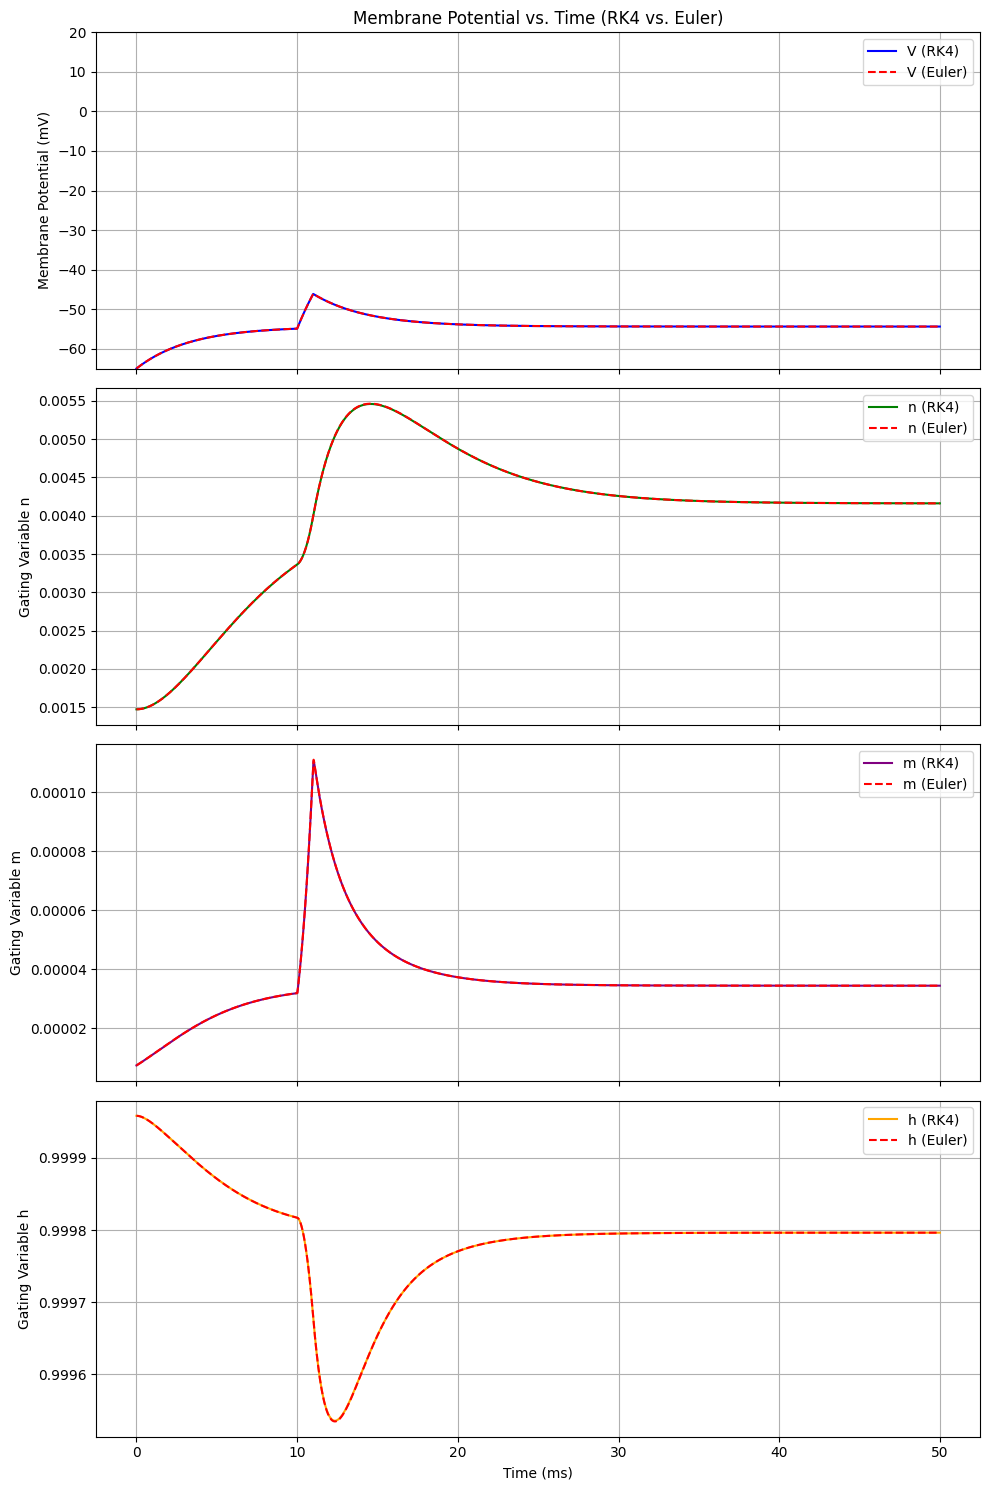

Detailed plots comparing RK4 and Forward Euler results generated successfully.


In [15]:
import matplotlib.pyplot as plt

# Create a figure with 4 subplots, sharing the x-axis (time)
fig, (ax_V, ax_n, ax_m, ax_h) = plt.subplots(4, 1, figsize=(10, 15), sharex=True)

# Plot Membrane Potential (V)
ax_V.plot(t, V_trace_rk4, label='V (RK4)', color='blue')
ax_V.plot(t, V_trace, label='V (Euler)', color='red', linestyle='--')
ax_V.set_ylabel('Membrane Potential (mV)')
ax_V.set_title('Membrane Potential vs. Time (RK4 vs. Euler)')
ax_V.set_ylim(-65, 20) # Set y-axis limits
ax_V.grid(True)
ax_V.legend()

# Plot Gating Variable n
ax_n.plot(t, n_trace_rk4, label='n (RK4)', color='green')
ax_n.plot(t, n_trace, label='n (Euler)', color='red', linestyle='--')
ax_n.set_ylabel('Gating Variable n')
ax_n.grid(True)
ax_n.legend()

# Plot Gating Variable m
ax_m.plot(t, m_trace_rk4, label='m (RK4)', color='purple')
ax_m.plot(t, m_trace, label='m (Euler)', color='red', linestyle='--')
ax_m.set_ylabel('Gating Variable m')
ax_m.grid(True)
ax_m.legend()

# Plot Gating Variable h
ax_h.plot(t, h_trace_rk4, label='h (RK4)', color='orange')
ax_h.plot(t, h_trace, label='h (Euler)', color='red', linestyle='--')
ax_h.set_xlabel('Time (ms)')
ax_h.set_ylabel('Gating Variable h')
ax_h.grid(True)
ax_h.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

print("Detailed plots comparing RK4 and Forward Euler results generated successfully.")

The above code, gives the HH model graph using the RK4 (Runge-Kutte 4th order) approach to generate the graph at the time points chosen. This approach, also takes into account the slope at the mid point of the equation evolution time dt for a better estimate of the graph at each time point, following the equation.   

```markdown
`y(t + dt) = y(t) + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)`

Where:
- `k1 = dt * f(t, y)`
- `k2 = dt * f(t + 0.5*dt, y + 0.5*k1)`
- `k3 = dt * f(t + 0.5*dt, y + 0.5*k2)`
- `k4 = dt * f(t + dt, y + k3)`

And `f(t, y)` represents the derivative `dy/dt` at a given time `t` and state `y`.
```

As is seen, there is not much difference in the graphs between the euler method and the RK4 method.

In order to get the graphs that are found in neural simulation books, I have to take a smaller dt.